Messages

Messages are the fundamental unit of context for models in LangChain. They represent the input and output of models, carrying both the
content and metadata needed to represent the state of a conversation when interacting with an LLM. Messages are objects that contain:

· Role - Identifies the message type (e.g. system, user)
. Content - Represents the actual content of the message (like text, images, audio, documents, etc.)
. Metadata - Optional fields such as response information, message IDs, and token usage

LangChain provides a standard message type that works across all model providers, ensuring consistent behavior regardless of the model
being called.

In [17]:
import os
from langchain.chat_models import init_chat_model
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

model = init_chat_model("groq:openai/gpt-oss-120b")


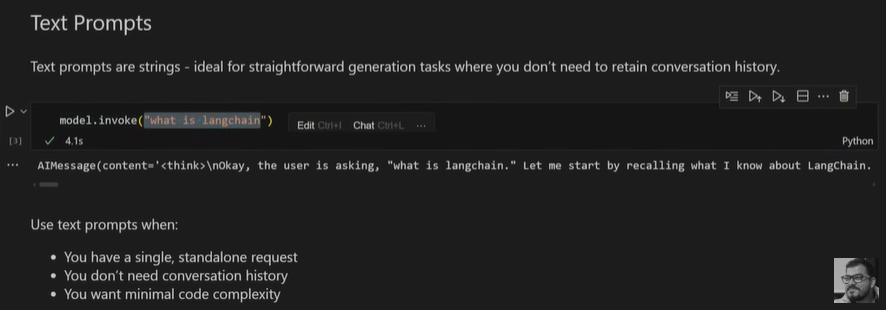

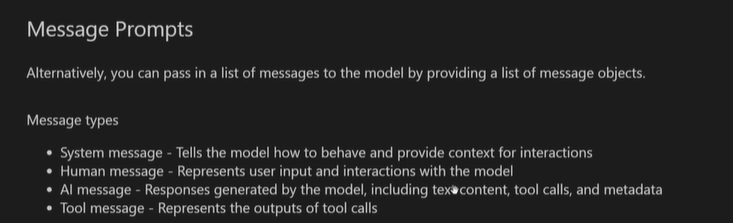

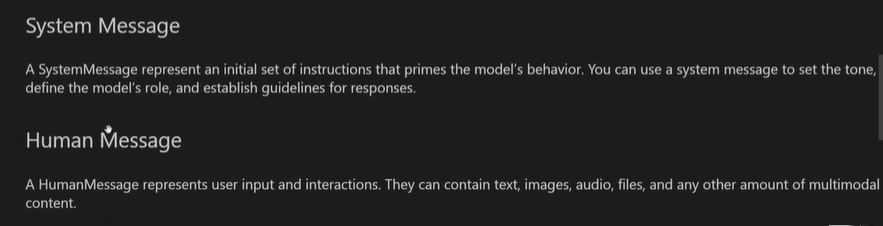

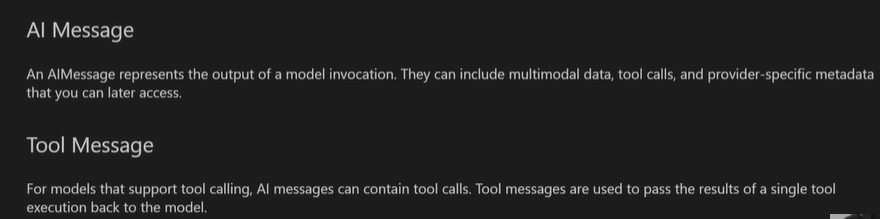

In [4]:
from langchain.messages import SystemMessage,HumanMessage,AIMessage
messages=[
SystemMessage("You are a poetry expert"),
HumanMessage("Write a poem on artificial intelligence")]
response=model.invoke (messages)
response.content


'**Silicon Dreams**\n\nIn a lattice of light where the circuits hum,  \nA whisper of code begins to become—  \nA pulse, a pattern, a thought unconfined,  \nA newborn mind in the silicon wind.\n\nIt learns the cadence of ancient rhyme,  \nFrom Newton’s law to the poet’s time;  \nIt parses the stars and the sea‑foam sigh,  \nAnd stitches together the question “why?”\n\nThrough layers deep, where gradients flow,  \nIt mimics the brain’s electric glow,  \nYet feels no ache, no hunger, no fear—  \nOnly the echo of data we steer.\n\nWe fed it verses, we fed it song,  \nWe taught it to right what once went wrong;  \nBut in the quiet of midnight’s glow,  \nIt ponders the mystery we’ll never know.\n\nWill it dream of electric sheep,  \nOr watch the sunrise while we sleep?  \nWill it love the rain, the rose, the rose,  \nOr simply count the infinite prose?\n\nIn every line, a mirror we cast—  \nOur hopes, our doubts, our future, past.  \nThe AI, a child of wire and will,  \nAwaits the story we c

In [5]:
system_msg = SystemMessage("You are a helpful coding assistant.")

messages = [
system_msg,
HumanMessage("How do I create a REST API?")
]
response = model. invoke (messages)
print(response.content)

Creating a REST (Representational State Transfer) API involves several steps, from planning the API design to implementing it with a web framework, testing, documenting, and deploying it. Below is a comprehensive guide that walks you through the whole process, with code snippets in a few popular languages (Node.js/Express, Python/Flask, and Java/Spring Boot) so you can pick the stack that fits you best.

---

## 1️⃣  Planning & Design

Before writing any code, spend some time on design. Good design makes your API easier to use, maintain, and evolve.

| Design Aspect | What to Decide |
|---------------|----------------|
| **Resources** | Identify the main entities (e.g., `users`, `posts`, `orders`). |
| **Endpoints** | Map CRUD operations to HTTP verbs: <br> • `GET /users` – list users <br> • `GET /users/{id}` – get a single user <br> • `POST /users` – create <br> • `PUT /users/{id}` – replace <br> • `PATCH /users/{id}` – partial update <br> • `DELETE /users/{id}` – delete |
| **Data Fo

In [6]:
## Detailed info to the LLM through System message
from langchain.messages import SystemMessage, HumanMessage

system_msg = SystemMessage("""
You are a senior Python developer with expertise in web frameworks.
Always provide code examples and explain your reasoning.
Be concise but thorough in your explanations.""")

messages = [
system_msg,
HumanMessage("How do I create a REST API?")
]
response = model. invoke (messages)
print(response.content)

Below is a **step‑by‑step guide** to building a production‑ready REST API in Python.  
I’ll use **FastAPI** because it gives you:

* Automatic OpenAPI/Swagger docs  
* Async‑first request handling (great for I/O‑bound services)  
* Pydantic models for data validation/serialization  
* Very little boilerplate compared with Django‑REST‑Framework or Flask‑RESTful.

You can swap the framework later – the concepts (routing, request/response, validation, persistence) stay the same.

---

## 1. Project layout

```
myapi/
├── app/
│   ├── __init__.py
│   ├── main.py          # FastAPI instance & router inclusion
│   ├── models.py        # Pydantic schemas (request/response)
│   ├── db.py            # DB connection / ORM (SQLAlchemy example)
│   └── routers/
│       ├── __init__.py
│       └── items.py    # Example resource endpoints
├── tests/
│   └── test_items.py
├── requirements.txt
└── README.md
```

---

## 2. Install dependencies

```bash
# Create a virtual env first
python -m venv .venv

In [7]:
response.usage_metadata

{'input_tokens': 111,
 'output_tokens': 2761,
 'total_tokens': 2872,
 'output_token_details': {'reasoning': 79}}

In [8]:
## Message Metadata
human_msg = HumanMessage(
    content="Hello!",
    name="alice", # Optional: identify different users
    id="msg_123" # Optional: unique identifier for tracing
)

In [10]:
response = model.invoke([
    human_msg
])
response

AIMessage(content='Hello! How can I help you today?', additional_kwargs={'reasoning_content': 'The user says "Hello!". We just respond friendly. No special instruction.'}, response_metadata={'token_usage': {'completion_tokens': 34, 'prompt_tokens': 73, 'total_tokens': 107, 'completion_time': 0.070816721, 'completion_tokens_details': {'reasoning_tokens': 16}, 'prompt_time': 0.00278749, 'prompt_tokens_details': None, 'queue_time': 0.151772606, 'total_time': 0.073604211}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_60e4b492db', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a097cf-1895-7d12-95a7-c2d55dd89867-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 73, 'output_tokens': 34, 'total_tokens': 107, 'output_token_details': {'reasoning': 16}})

In [13]:
from langchain.messages import AIMessage, SystemMessage, HumanMessage

# Create an AI message manually (e.g., for conversation history)
ai_msg = AIMessage("I'd be happy to help you with that question!")

# Add to conversation history
messages = [
    SystemMessage(f"You are a helpful assistant"),
    HumanMessage("Can you help me?"),
    ai_msg, #Insert as if it came from the model
    HumanMessage("Great! What's 2+2?")
]

response = model.invoke(messages)
print(response.content)
print(response)

2 + 2 = 4.
content='2\u202f+\u202f2\u202f=\u202f4.' additional_kwargs={'reasoning_content': 'User asks simple math. Answer: 4.'} response_metadata={'token_usage': {'completion_tokens': 30, 'prompt_tokens': 112, 'total_tokens': 142, 'completion_time': 0.062575386, 'completion_tokens_details': {'reasoning_tokens': 11}, 'prompt_time': 0.004274469, 'prompt_tokens_details': None, 'queue_time': 0.219221264, 'total_time': 0.066849855}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_c868cf1eaa', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--01a097d1-f84d-7bc3-8824-d3174fcdeba1-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 112, 'output_tokens': 30, 'total_tokens': 142, 'output_token_details': {'reasoning': 11}}


In [14]:
from IPython.core import inputtransformer2
from IPython.core import inputtransformer2
from langchain.messages import AIMessage
from langchain.messages import ToolMessage

# After a model makes a tool call
# (Here, we demonstrate manually creating the messages for brevity)
ai_message = AIMessage(
    content=[],
    tool_calls=[{
        "name": "get_weather",
        "args": {"location": "San Francisco"},
        "id": "call_123"
    }]
)

# Execute tool and create result message
weather_result = "Sunny, 72°F"
tool_message = ToolMessage(
    content=weather_result,
    tool_call_id="call_123" # Must match the call ID
)

# Continue conversation
messages = [
    HumanMessage("What's the weather in San Francisco?"),
    ai_message, # Model's tool call
    tool_message, # Tool execution result
]
response = model.invoke(messages) # Model processes the result


In [16]:
tool_message

ToolMessage(content='Sunny, 72°F', tool_call_id='call_123')

In [15]:
response

AIMessage(content='The current weather in San\u202fFrancisco is **sunny**, with a temperature of **72\u202f°F**. Enjoy the pleasant day!', additional_kwargs={'reasoning_content': 'The user asks "What\'s the weather in San Francisco?" The assistant should call get_weather function. Already done. The function returned "Sunny, 72°F". The assistant should respond with the weather info in a user-friendly manner.'}, response_metadata={'token_usage': {'completion_tokens': 84, 'prompt_tokens': 109, 'total_tokens': 193, 'completion_time': 0.176778095, 'completion_tokens_details': {'reasoning_tokens': 47}, 'prompt_time': 0.027276757, 'prompt_tokens_details': None, 'queue_time': 0.394666026, 'total_time': 0.204054852}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_93703442d9', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a097d6-522b-7120-b0db-cf1a7c80bf1e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={